In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
current_pwd = os.getcwd()

possible_paths = [
    '/home/export/soheuny/SRFinder/soheun/notebooks', 
    '/home/soheuny/HH4bsim/soheun/notebooks'
]
    
assert os.getcwd() in possible_paths, f"Did you change the path? It should be one of {possible_paths}"
os.chdir("..")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import torch
import tqdm

from plots import hist_events_by_labels
from events_data import EventsData
from fvt_classifier import FvTClassifier
# import LogNorm
from matplotlib.colors import LogNorm
from training_info import TrainingInfo
from attention_classifier import AttentionClassifier
from plots import plot_rewighted_samples_by_model, plot_samples_raw
from dataset import MotherSamples
from events_data import events_from_scdinfo



features = [
    "sym_Jet0_pt", "sym_Jet1_pt", "sym_Jet2_pt", "sym_Jet3_pt",
    "sym_Jet0_eta", "sym_Jet1_eta", "sym_Jet2_eta", "sym_Jet3_eta",
    "sym_Jet0_phi", "sym_Jet1_phi", "sym_Jet2_phi", "sym_Jet3_phi",  
    "sym_Jet0_m", "sym_Jet1_m", "sym_Jet2_m", "sym_Jet3_m",
]

# use tex
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = "Times New Roman"

plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.titlesize"] = 20
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.labelsize"] = 15
plt.rcParams["figure.labelsize"] = 20
plt.rcParams["lines.markersize"] = 3

import pandas as pd


df_3b = pd.read_hdf("../events/MG3/dataframes/threeTag_picoAOD.h5")
df_bg4b = pd.read_hdf("../events/MG3/dataframes/fourTag_10x_picoAOD.h5")
df_signal = pd.read_hdf("../events/MG3/dataframes/HH4b_picoAOD.h5")
df_3b["signal"] = False
df_bg4b["signal"] = False
df_signal["signal"] = True
raw_df_list = [df_3b, df_bg4b, df_signal]

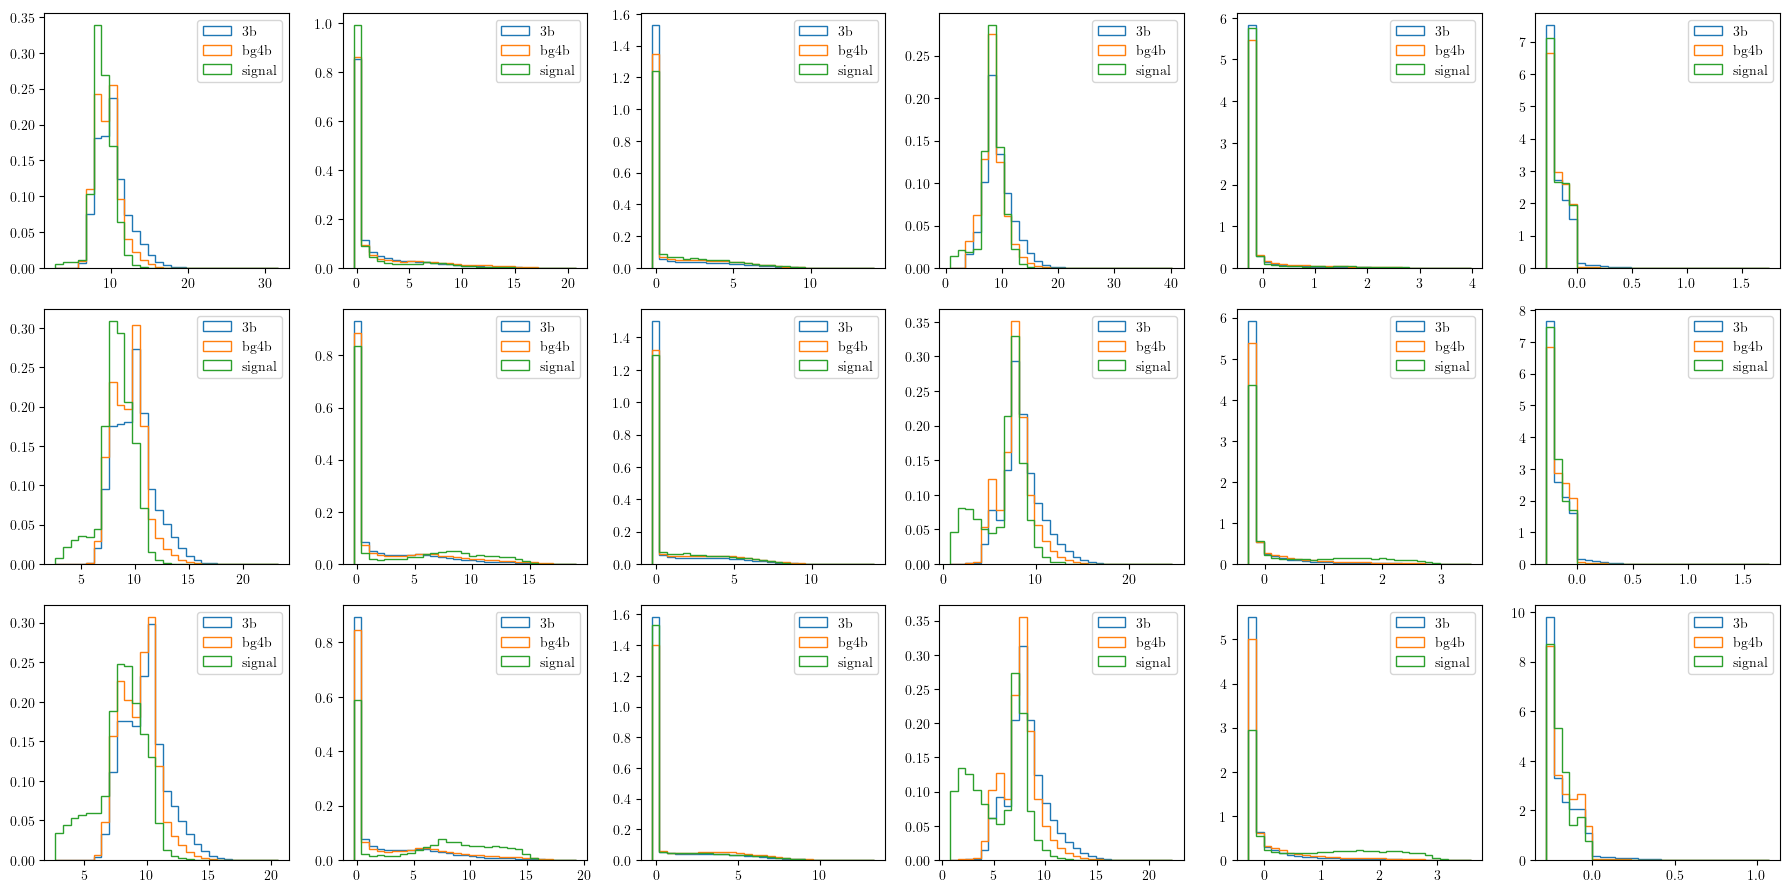

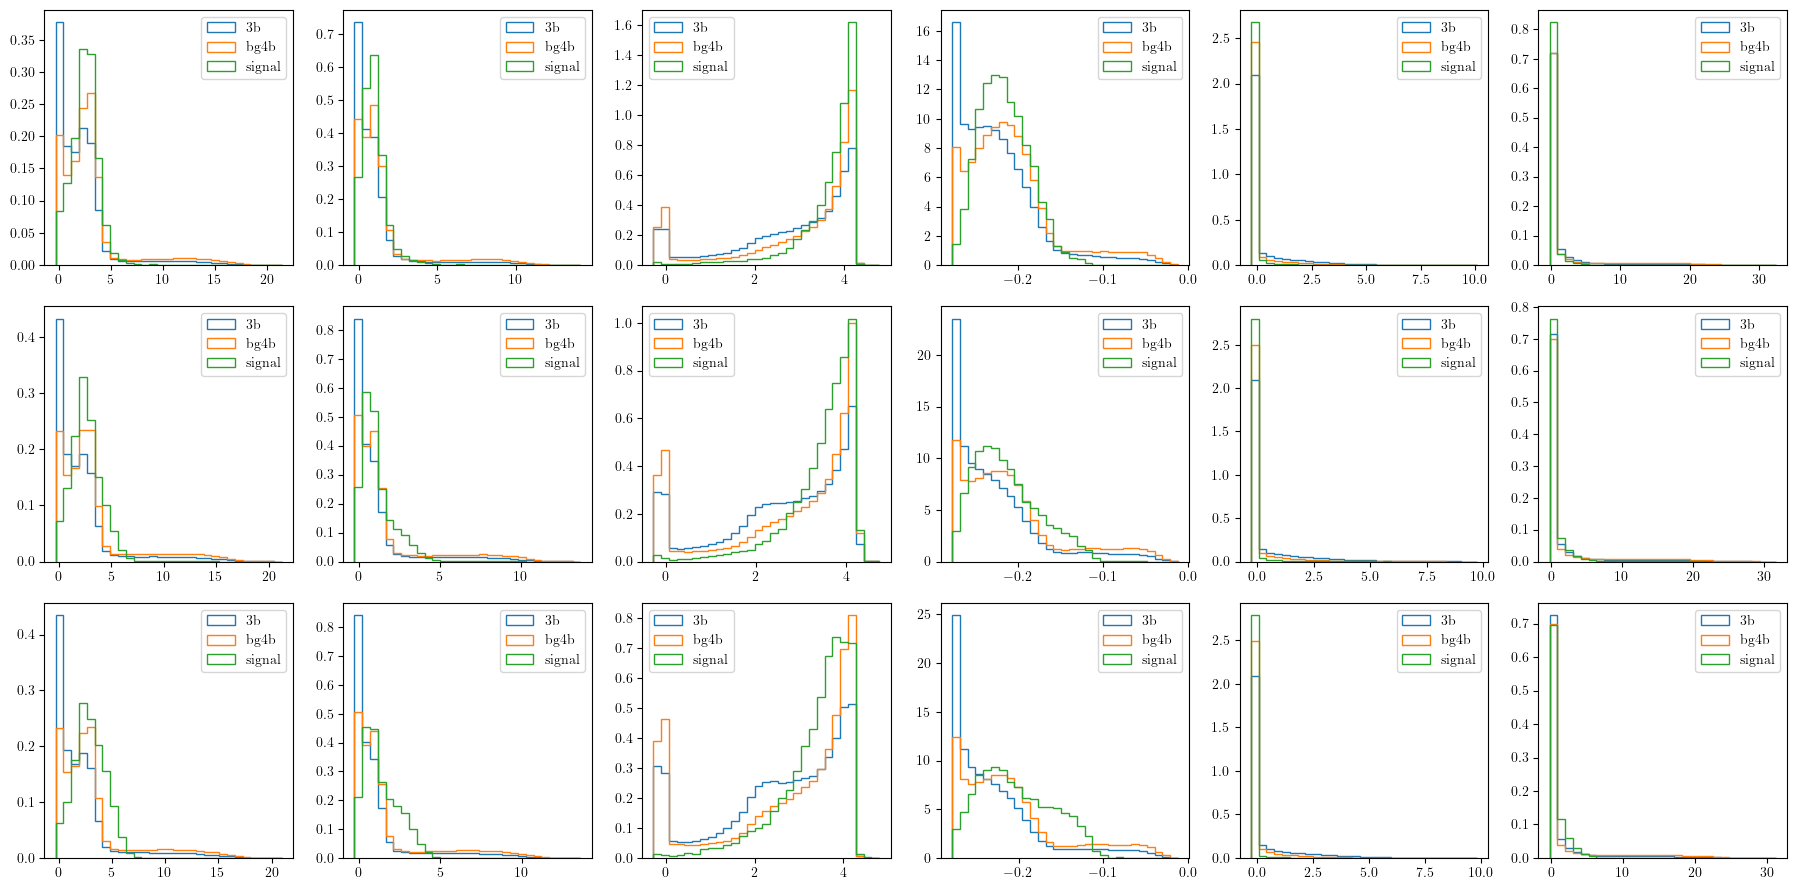

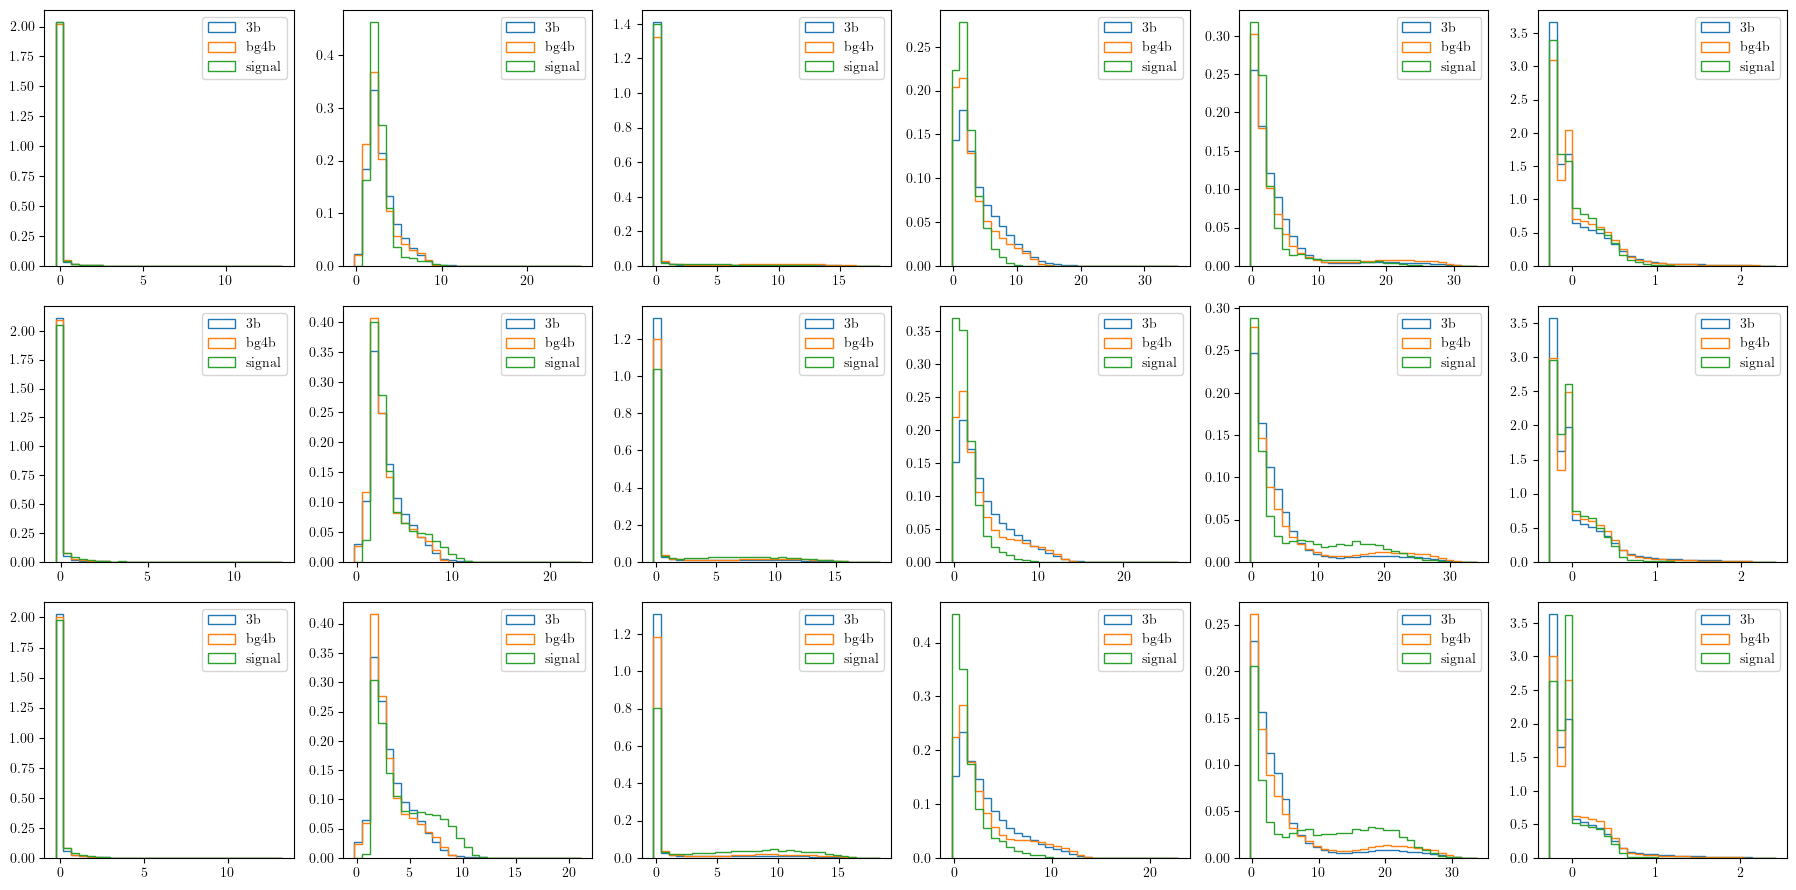

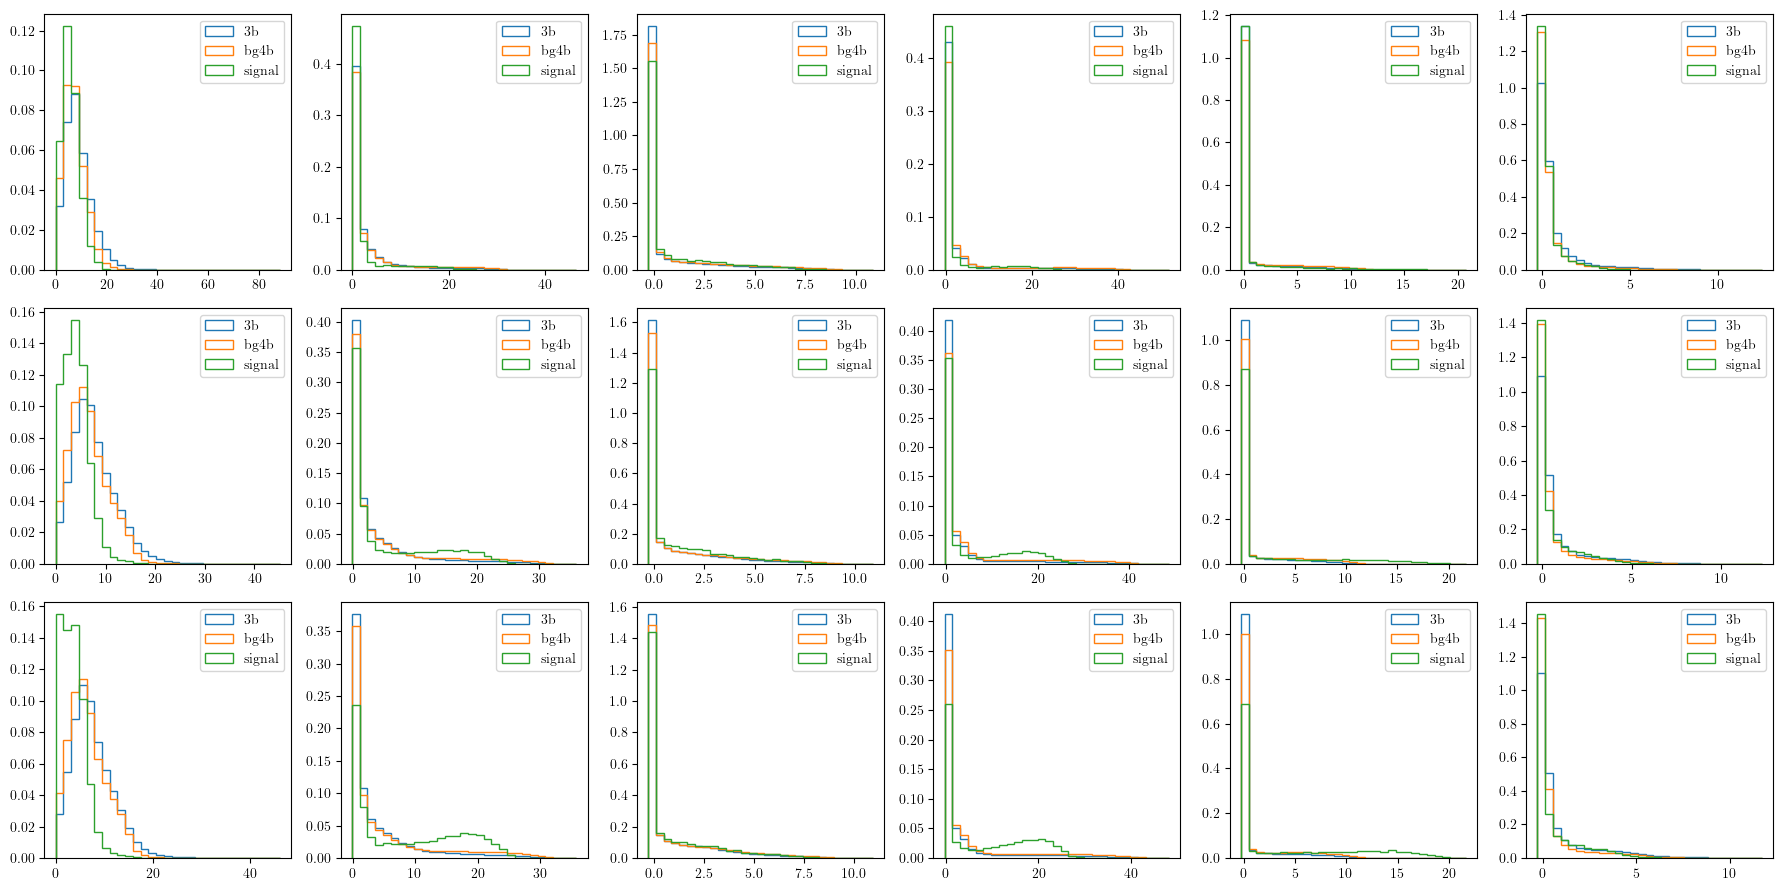

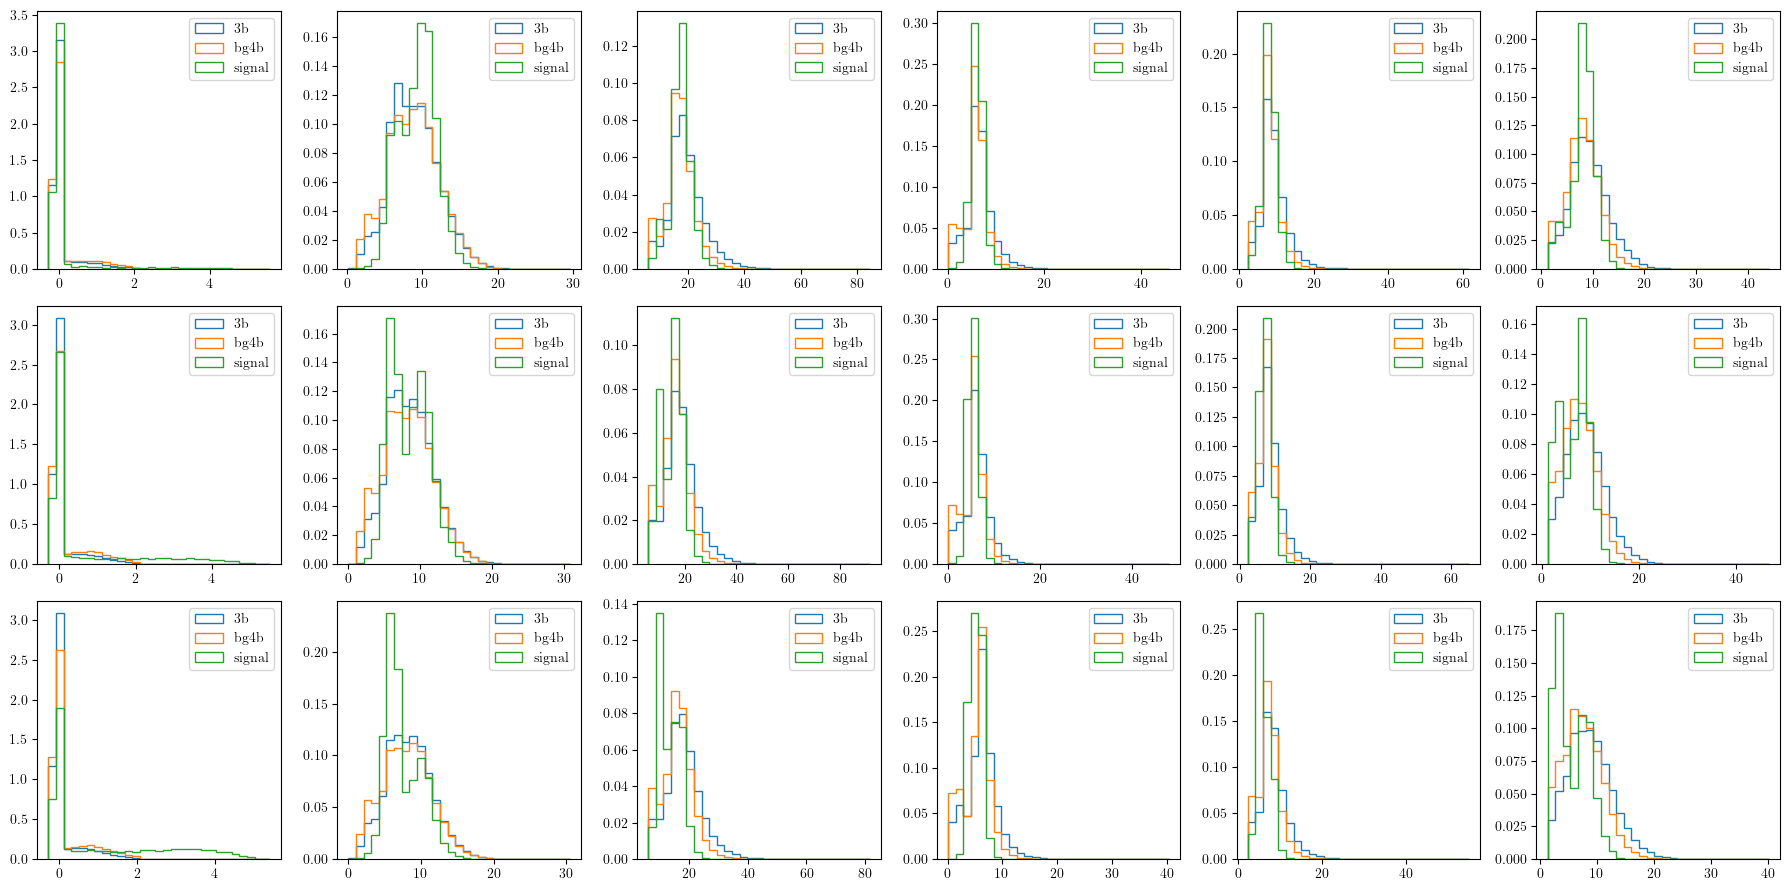

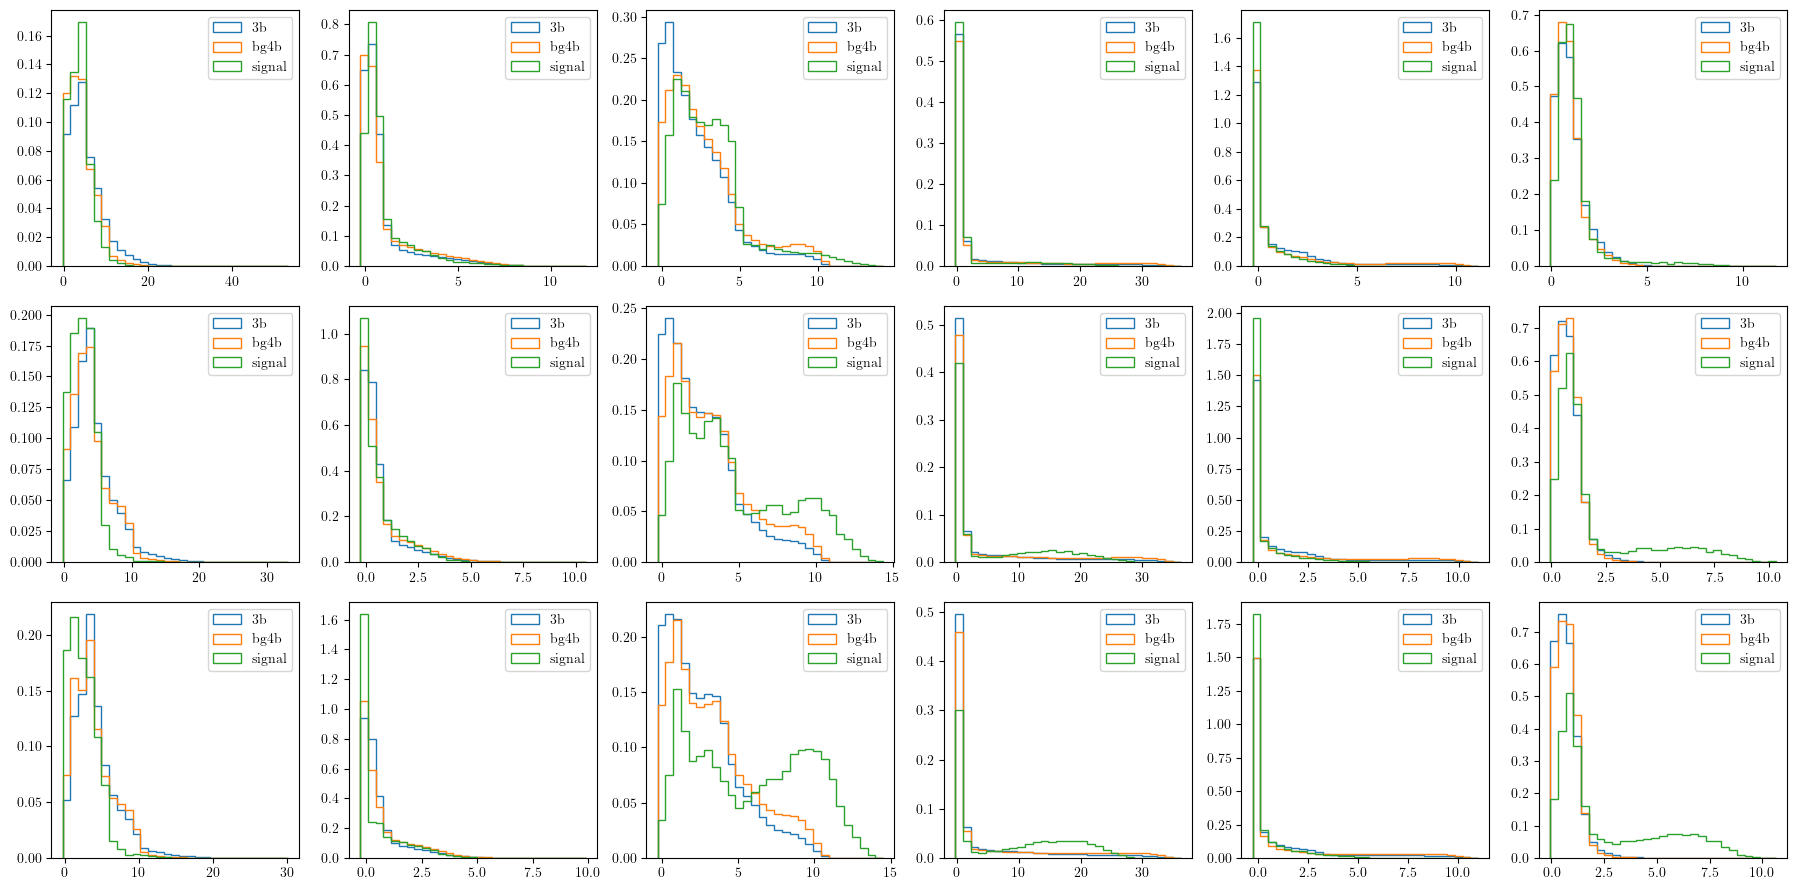

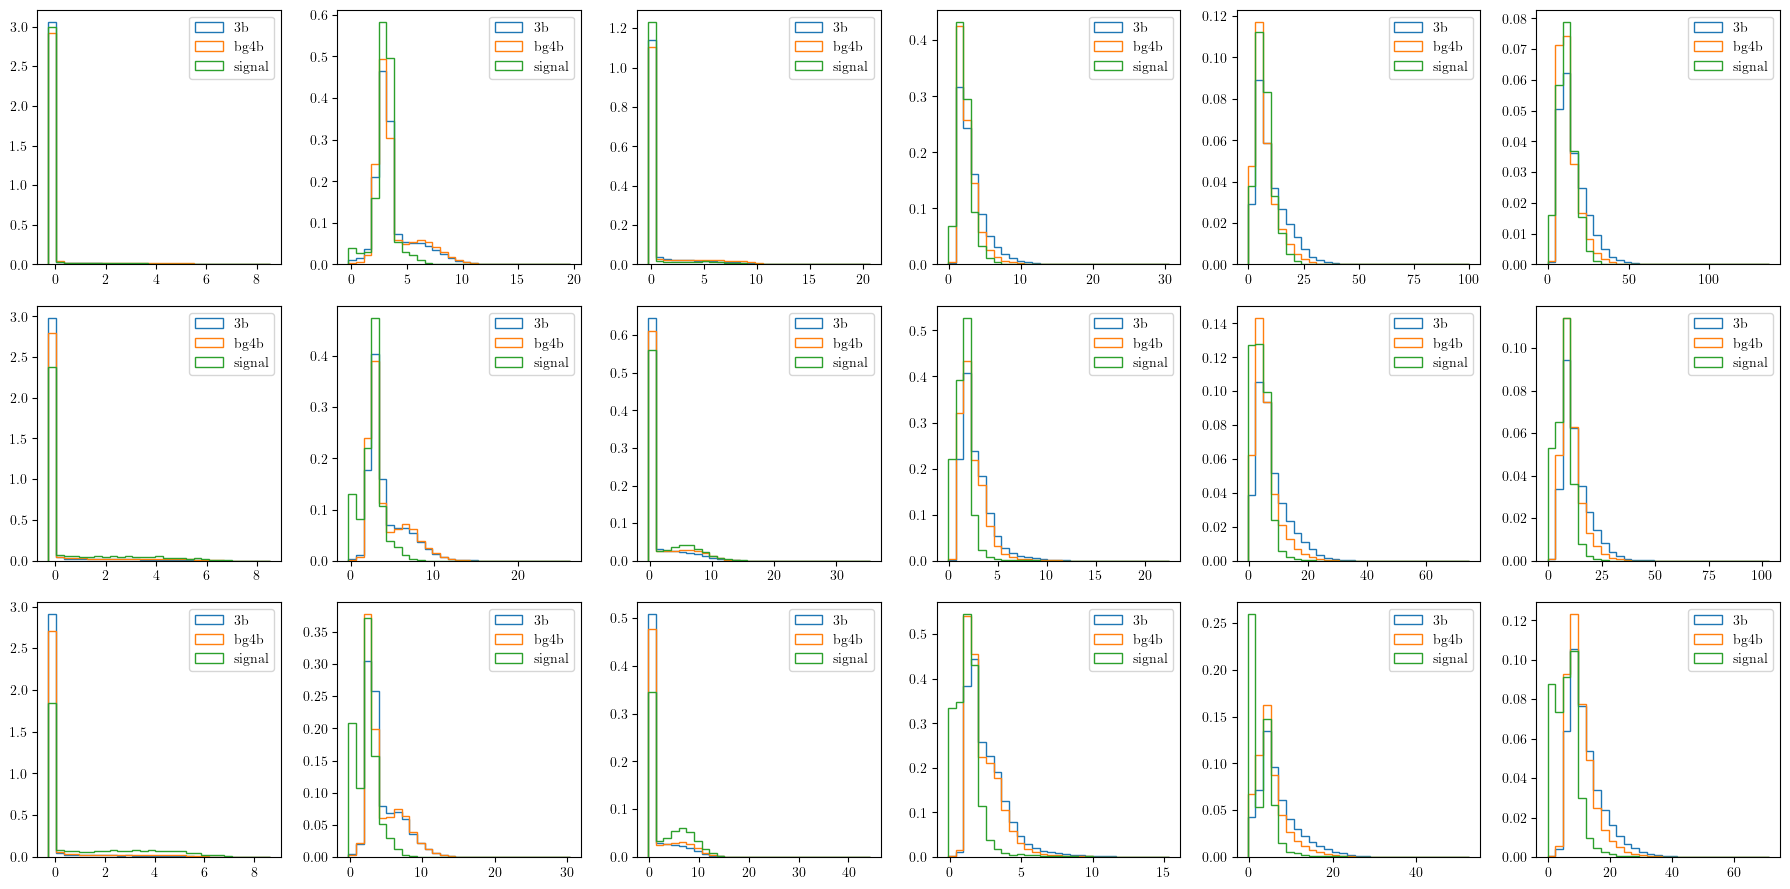

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7f9de8f3cf50>>
Traceback (most recent call last):
  File "/home/export/soheuny/.conda/envs/coffea_torch/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 770, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


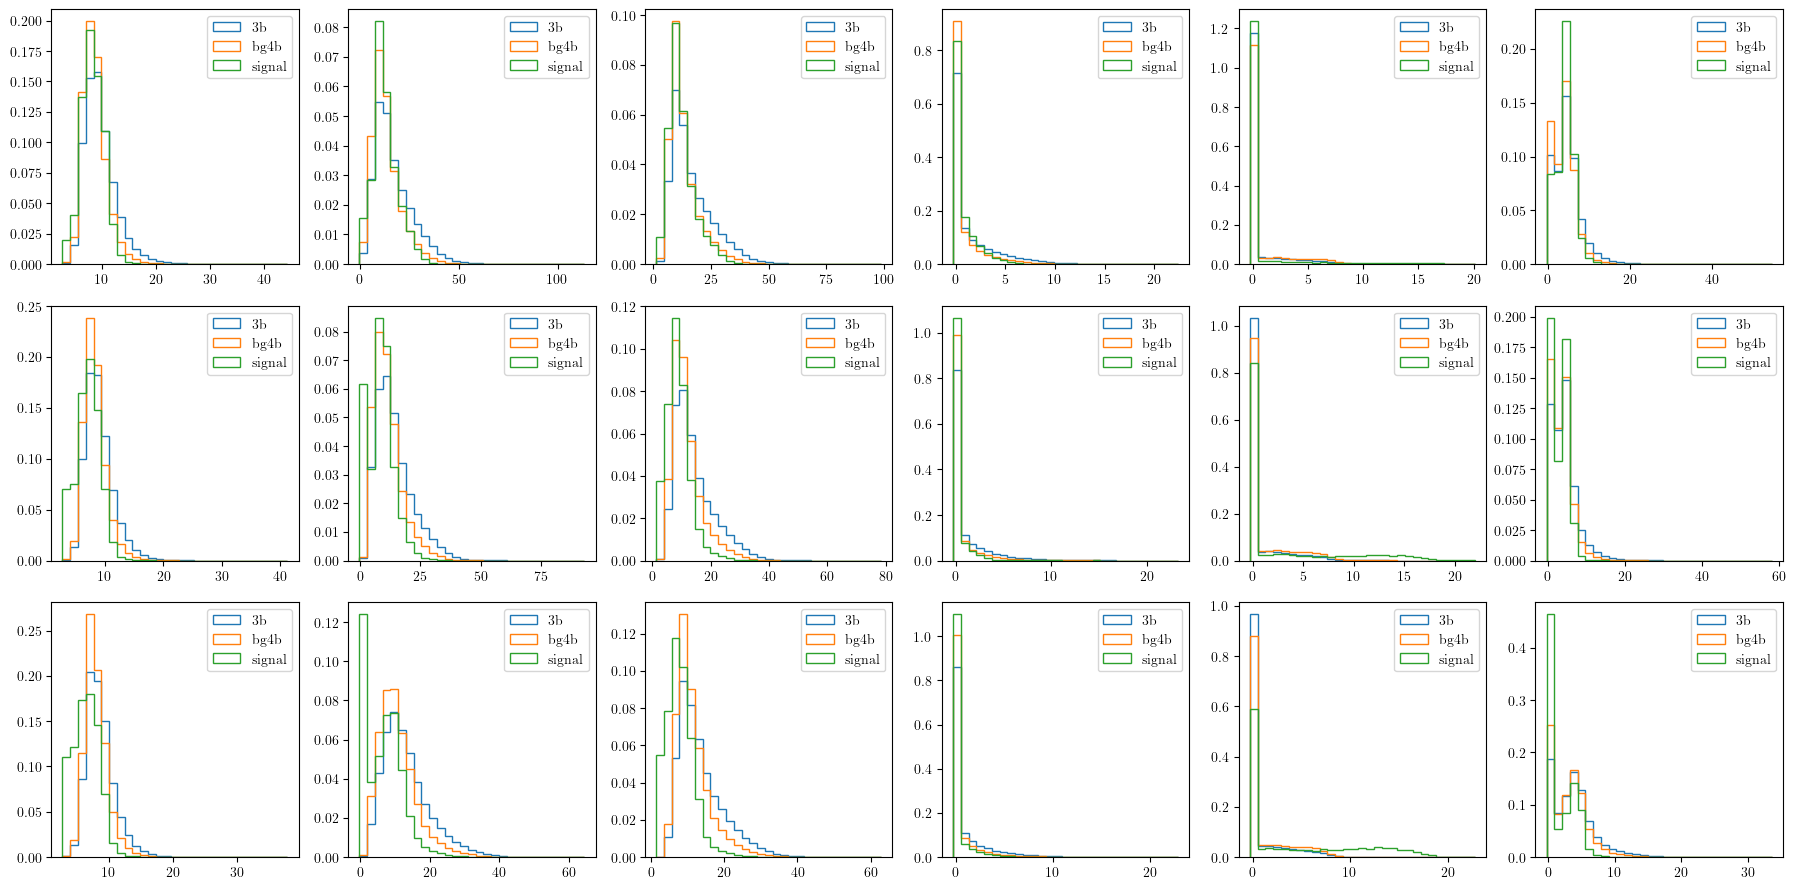

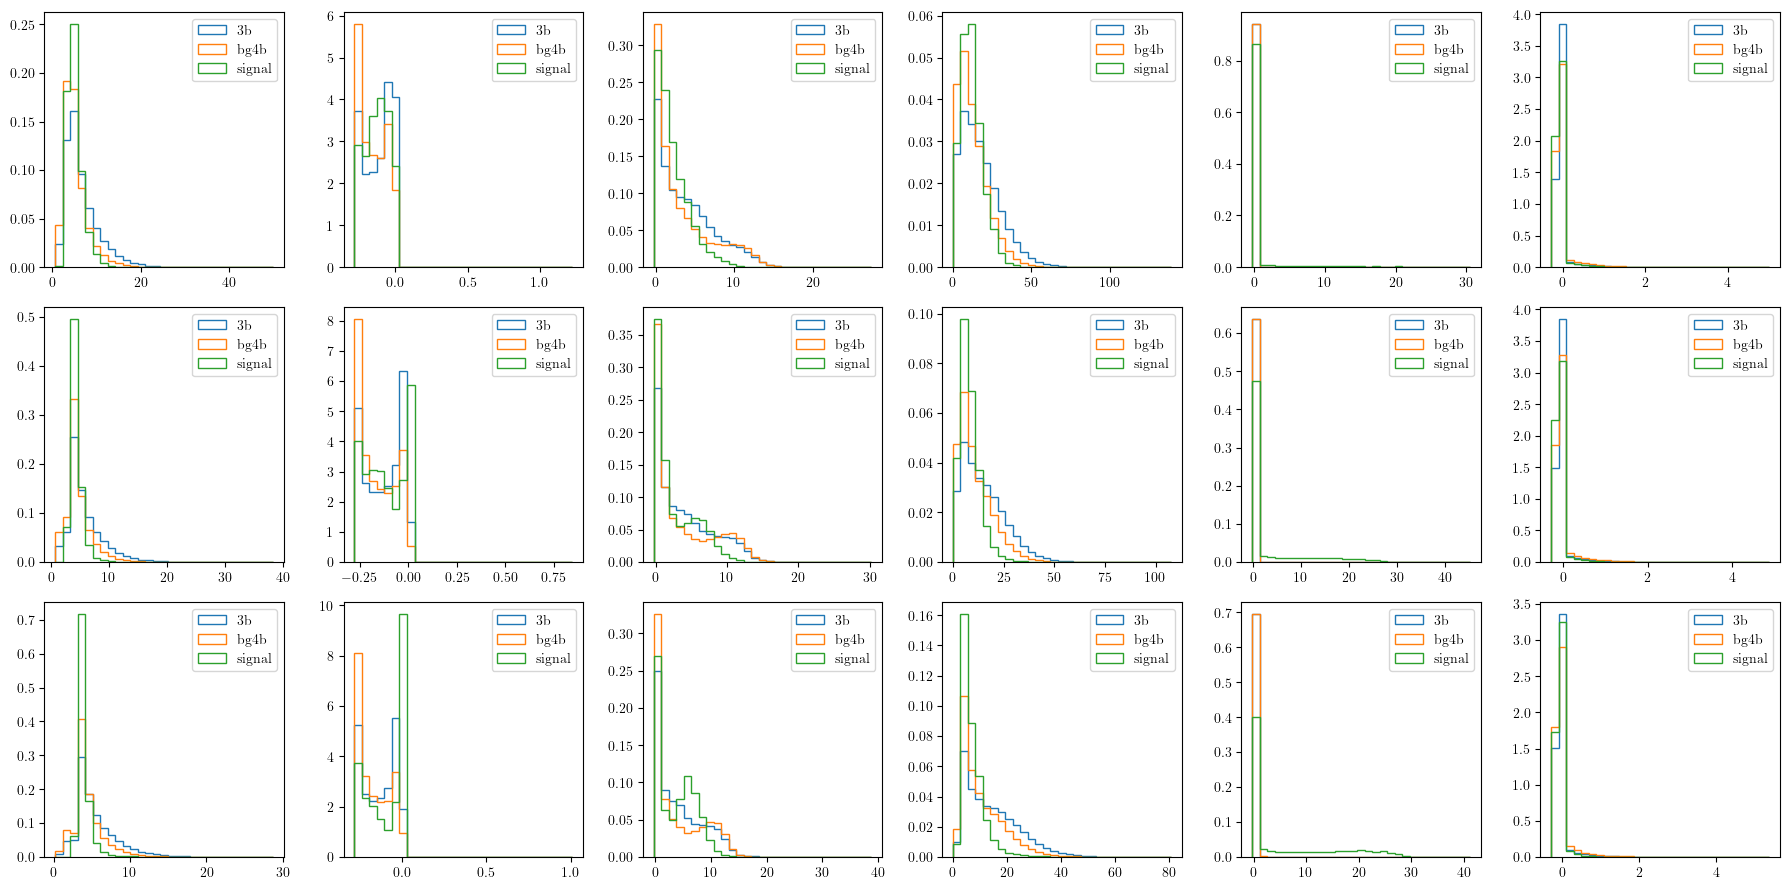

KeyboardInterrupt: 

In [6]:
hparams_filter = {
    "experiment_name": "better_base_fvt_training",
    "dataset": lambda x: x["signal_ratio"] == 0.02,
}
hashes = TrainingInfo.find(hparams_filter)

for hash in hashes:
    base_fvt_info = TrainingInfo.load(hash)
    base_fvt_model = base_fvt_info.load_trained_model("best")
    base_fvt_model: FvTClassifier
    base_fvt_model.eval()
    base_fvt_model.to("cuda")

    ms_hash = base_fvt_info.ms_hash
    ms_idx = base_fvt_info.ms_idx
    msamples = MotherSamples.load(ms_hash)
    tst_scdinfo = msamples.scdinfo[~ms_idx]
    df_tst = tst_scdinfo.fetch_data_with_loaded_df(raw_df_list)
    events_tst = EventsData.from_dataframe(df_tst, features)
    
    base_fvt_scores, base_q_repr = base_fvt_model.predict_and_representations(events_tst.X_torch)
    base_fvt_scores = base_fvt_scores.numpy()[:, 1]
    base_q_repr = base_q_repr.numpy()
    
    ncols, nrows = base_q_repr.shape[1], base_q_repr.shape[2]
    fig, axs = plt.subplots(nrows, ncols, figsize=(ncols*3, nrows*3))
    for i in range(nrows):
        for j in range(ncols):
            bins = np.linspace(base_q_repr[:, j, i].min(), base_q_repr[:, j, i].max(), 30)
            hist_events_by_labels(events_tst, base_q_repr[:, j, i], bins=bins, ax=axs[i, j], density=True)
            axs[i, j].legend()
    plt.tight_layout()
    plt.show()

    